# PhasorFlow — Financial Analysis with Phasor Circuits

## From OHLCV to the Unit Circle: Phasor-Based Market Intelligence

This notebook demonstrates how **phasor computing on the unit circle** provides a rich, non-linear framework for financial analysis. By encoding market data as phases and amplitudes, we leverage the structure of $S^1$ (the unit circle manifold) to detect patterns invisible to traditional linear methods.

**Data Generation:** All examples use **Geometric Brownian Motion (GBM)** — the standard stochastic model for asset prices — to generate realistic OHLCV data.

| # | Application | Gates Used | Financial Concept |
|---|-------------|-----------|-------------------|
| 1 | GBM Data Generator | — | Simulating realistic OHLCV data |
| 2 | Phase Coherence Crisis Detector | Shift, Mix, DFT | Volatility regime detection |
| 3 | Phasor Momentum Oscillator | Shift, Accumulate, Normalize | Trend-following indicator |
| 4 | Market Regime Classifier | Shift, Kuramoto, Threshold | Bull/Bear/Sideways detection |
| 5 | Phasor Pair-Trading Signal | Shift, CrossCorrelate, Threshold | Statistical arbitrage |
| 6 | Volatility Surface Attractor | Shift, Hebbian, Saturate | Term-structure regime |

In [1]:
import sys, os, shutil
parent = os.path.abspath(os.path.join(os.path.dirname('__file__'), '..', '..'))
if parent not in sys.path:
    sys.path.insert(0, parent)
for root, dirs, _ in os.walk(os.path.join(parent, 'PhasorFlow')):
    for d in dirs:
        if d == '__pycache__':
            shutil.rmtree(os.path.join(root, d), ignore_errors=True)
for key in list(sys.modules.keys()):
    if 'phasorflow' in key.lower():
        del sys.modules[key]

import phasorflow as pf
from phasorflow import PhasorCircuit
from phasorflow.engine.analytic import AnalyticEngine
from phasorflow.gates import *
import torch
import math
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from datetime import datetime, timedelta

torch.manual_seed(42)
np.random.seed(42)
engine = AnalyticEngine()

def print_circuit_stats(circ):
    print(f"  Circuit:  {circ.name}")
    print(f"  Threads:  {circ.num_threads}, Gates: {circ.gate_count}, Depth: {circ.depth}")

def print_results(result):
    print(f"  Phases:     {result['phases']}")
    print(f"  Amplitudes: {result['amplitudes']}")

print(f"phasorflow v{pf.__version__} loaded")

phasorflow v0.2.0 loaded


---
## 1. Geometric Brownian Motion — Realistic OHLCV Simulator

The standard model for an asset price $S_t$ follows:

$$dS_t = \mu\, S_t\, dt + \sigma\, S_t\, dW_t$$

where $\mu$ is the drift (expected return), $\sigma$ is volatility, and $W_t$ is a Wiener process. This gives the closed-form solution:

$$S_t = S_0 \exp\!\left[\left(\mu - \tfrac{\sigma^2}{2}\right)t + \sigma W_t\right]$$

We inject a **crisis regime** (days 150–200) with $5\times$ volatility to test our detectors.

  1. GBM-Based OHLCV Data Generator


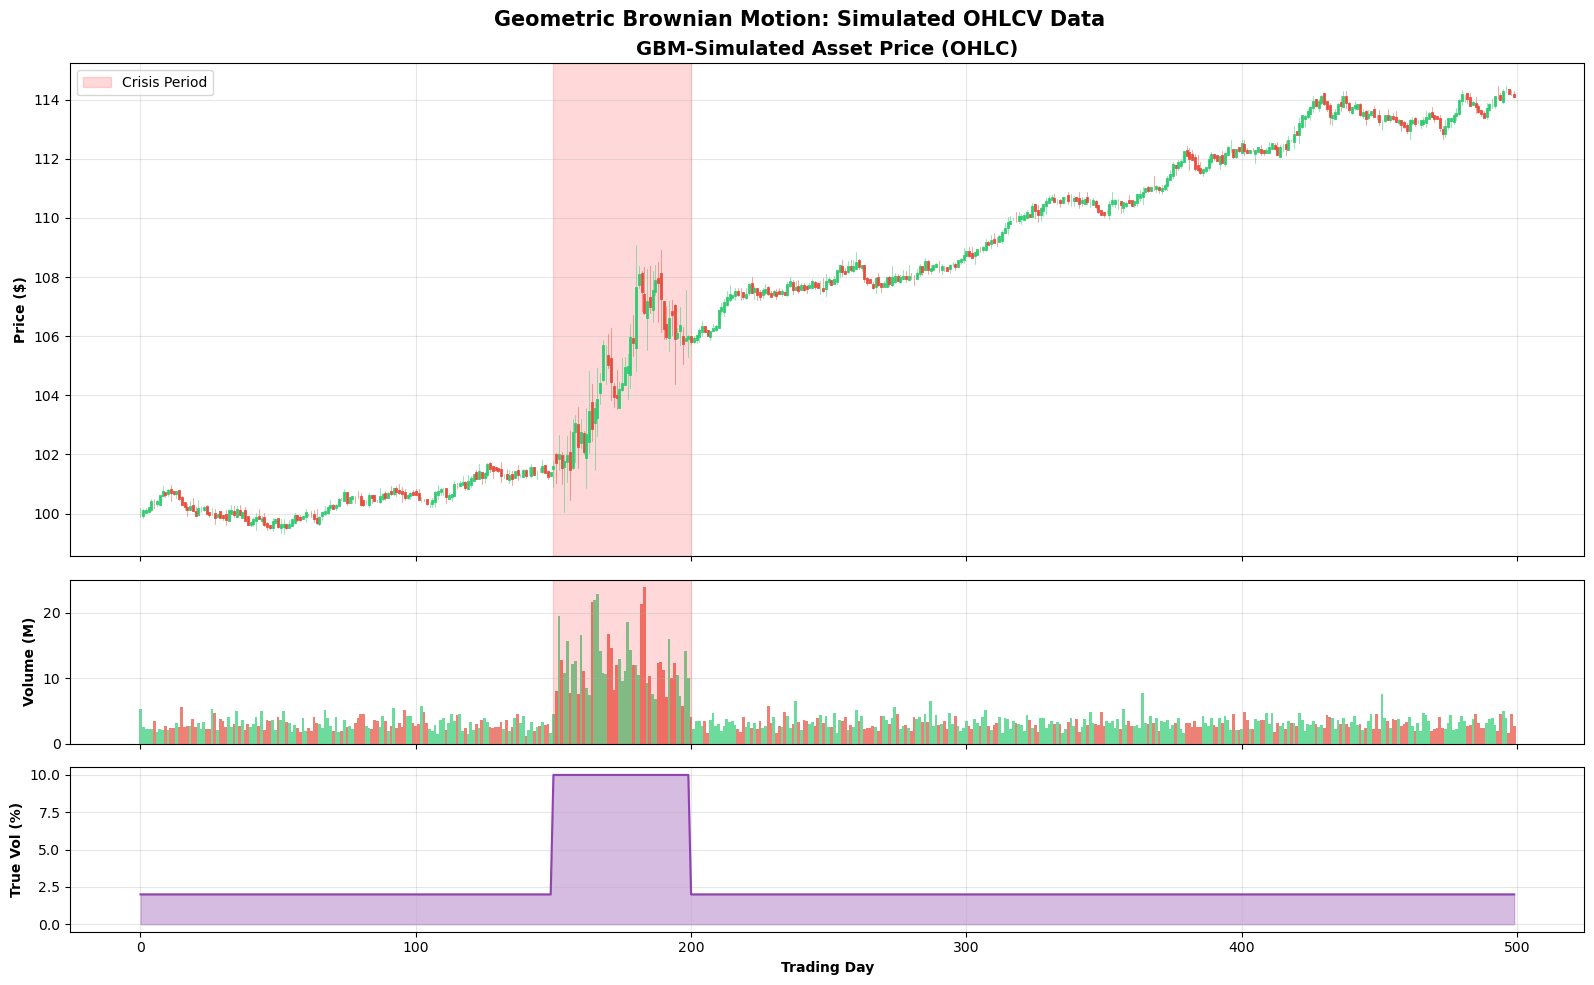


  Generated 500 trading days
  Price range: $99.32 — $114.47
  Crisis period: days 150–200
  Normal vol: 2.0%  |  Crisis vol: 10.0%


In [2]:
print("=" * 65)
print("  1. GBM-Based OHLCV Data Generator")
print("=" * 65)

def generate_gbm_ohlcv(n_days=500, S0=100.0, mu=0.05, sigma=0.02,
                        crisis_start=150, crisis_end=200, crisis_sigma_mult=5.0,
                        seed=42):
    # Generate realistic OHLCV data from Geometric Brownian Motion.
    # n_days: trading days, S0: initial price, mu: drift, sigma: volatility
    # crisis_start/end: crisis boundaries, crisis_sigma_mult: vol multiplier
    np.random.seed(seed)
    dt = 1/252  # One trading day

    # Build time-varying volatility
    sigma_t = np.full(n_days, sigma)
    sigma_t[crisis_start:crisis_end] *= crisis_sigma_mult

    # GBM price path (close prices)
    close = np.zeros(n_days)
    close[0] = S0
    for t in range(1, n_days):
        z = np.random.standard_normal()
        close[t] = close[t-1] * np.exp((mu - 0.5*sigma_t[t]**2)*dt + sigma_t[t]*np.sqrt(dt)*z)

    # Generate intraday OHLV from close
    open_p = np.zeros(n_days)
    high_p = np.zeros(n_days)
    low_p  = np.zeros(n_days)
    volume = np.zeros(n_days)

    open_p[0] = S0
    for t in range(n_days):
        if t > 0:
            # Open = previous close + small gap
            gap = np.random.normal(0, sigma_t[t]*close[t-1]*np.sqrt(dt)*0.3)
            open_p[t] = close[t-1] + gap

        # Intraday range driven by volatility
        intraday_vol = sigma_t[t] * close[t] * np.sqrt(dt)
        high_p[t] = max(open_p[t], close[t]) + abs(np.random.normal(0, intraday_vol))
        low_p[t]  = min(open_p[t], close[t]) - abs(np.random.normal(0, intraday_vol))

        # Volume proportional to volatility (more vol → more trading)
        base_vol = 1_000_000
        volume[t] = base_vol * (1 + 2*sigma_t[t]/sigma) * np.random.lognormal(0, 0.3)

    # Trading dates
    dates = [datetime(2024, 1, 2) + timedelta(days=int(i*365/252)) for i in range(n_days)]

    return {
        'dates': dates,
        'open': open_p, 'high': high_p, 'low': low_p, 'close': close,
        'volume': volume, 'sigma_t': sigma_t,
        'crisis_start': crisis_start, 'crisis_end': crisis_end,
    }

# Generate data
data = generate_gbm_ohlcv()

# ── Visualization ──
fig, axes = plt.subplots(3, 1, figsize=(16, 10), sharex=True,
                         gridspec_kw={'height_ratios': [3, 1, 1]})

# Price chart with candlestick-style coloring
ax = axes[0]
for t in range(len(data['dates'])):
    color = '#2ecc71' if data['close'][t] >= data['open'][t] else '#e74c3c'
    ax.plot([t, t], [data['low'][t], data['high'][t]], color=color, lw=0.5, alpha=0.7)
    ax.plot([t, t], [min(data['open'][t], data['close'][t]),
                     max(data['open'][t], data['close'][t])], color=color, lw=2)
ax.axvspan(data['crisis_start'], data['crisis_end'], alpha=0.15, color='red', label='Crisis Period')
ax.set_ylabel('Price ($)', fontweight='bold')
ax.set_title('GBM-Simulated Asset Price (OHLC)', fontweight='bold', fontsize=14)
ax.legend()
ax.grid(True, alpha=0.3)

# Volume
ax = axes[1]
colors = ['#2ecc71' if data['close'][t] >= data['open'][t] else '#e74c3c'
          for t in range(len(data['dates']))]
ax.bar(range(len(data['dates'])), data['volume']/1e6, color=colors, alpha=0.7, width=1)
ax.axvspan(data['crisis_start'], data['crisis_end'], alpha=0.15, color='red')
ax.set_ylabel('Volume (M)', fontweight='bold')
ax.grid(True, alpha=0.3)

# True volatility
ax = axes[2]
ax.fill_between(range(len(data['dates'])), data['sigma_t']*100, alpha=0.4, color='#9b59b6')
ax.plot(range(len(data['dates'])), data['sigma_t']*100, color='#8e44ad', lw=1.5)
ax.set_ylabel('True Vol (%)', fontweight='bold')
ax.set_xlabel('Trading Day', fontweight='bold')
ax.grid(True, alpha=0.3)

plt.suptitle('Geometric Brownian Motion: Simulated OHLCV Data', fontweight='bold', fontsize=15)
plt.tight_layout()
plt.show()

print(f"\n  Generated {len(data['dates'])} trading days")
print(f"  Price range: ${data['low'].min():.2f} — ${data['high'].max():.2f}")
print(f"  Crisis period: days {data['crisis_start']}–{data['crisis_end']}")
print(f"  Normal vol: {data['sigma_t'][0]*100:.1f}%  |  Crisis vol: {data['sigma_t'][data['crisis_start']]*100:.1f}%")

---
## 2. Phase Coherence Crisis Detector — Non-Linear Volatility Indicator

**Idea:** For each trading day, encode the 5 OHLCV features as phases on a 5-thread phasor circuit. Couple adjacent metrics (O→H→L→C) with `Mix` gates and blend globally with `DFT`. The **phase coherence** — $R = |\frac{1}{N}\sum_k e^{i\theta_k}|$ — of the output state measures how "aligned" the market features are.

During normal markets, features move in harmony → high coherence. During crises, they diverge → coherence drops. This creates a **non-linear volatility indicator**.

**Gates:** `shift` (encode) → `mix` (local coupling) → `dft` (global blend)

  2. Phase Coherence Crisis Detector


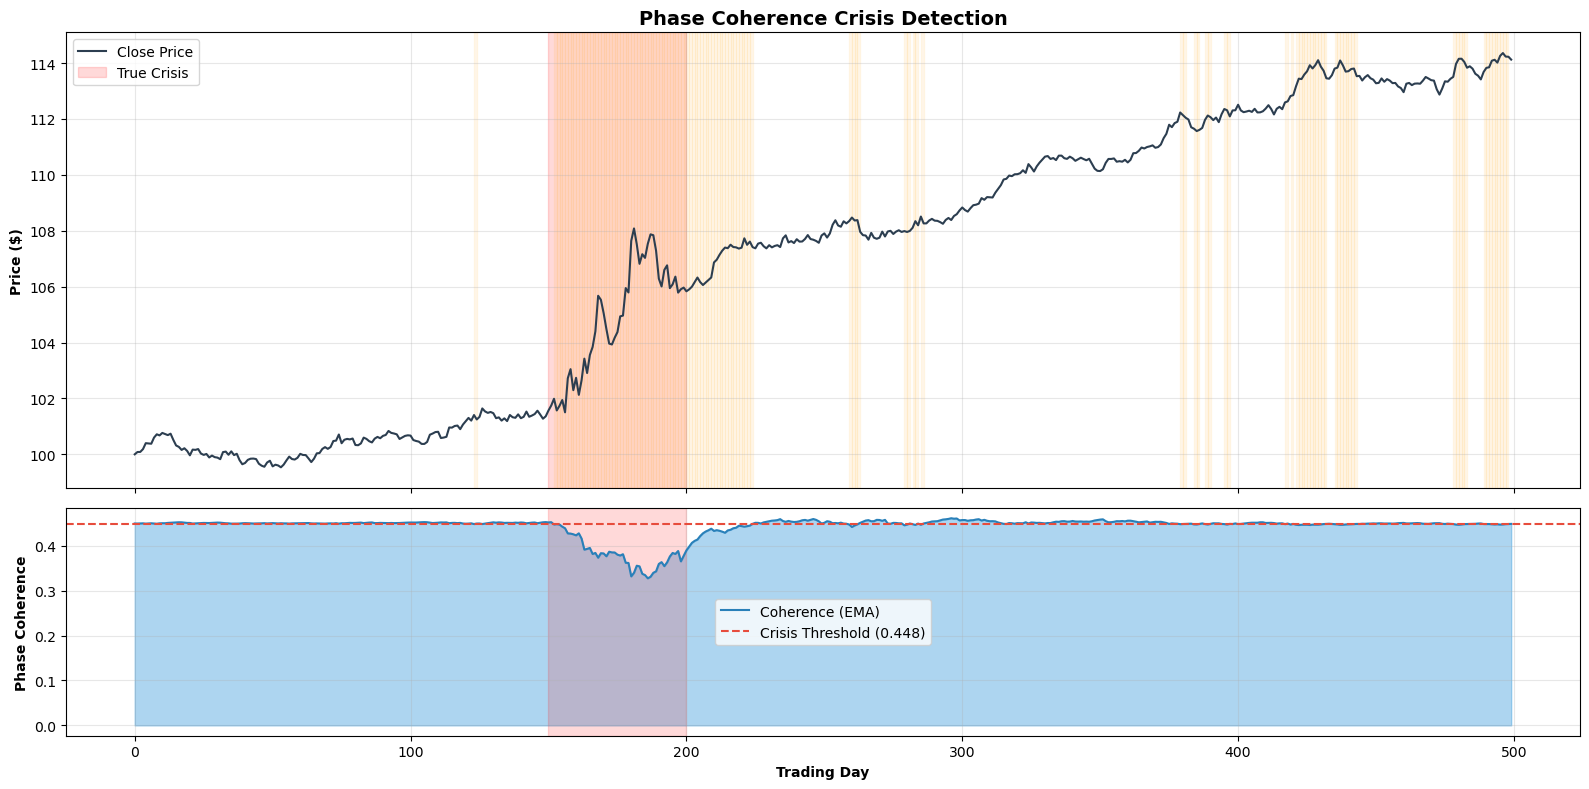


  Detection Results:
  Precision: 38.40%  |  Recall: 96.00%
  True positives: 48  |  False positives: 77  |  Missed: 2


In [3]:
print("=" * 65)
print("  2. Phase Coherence Crisis Detector")
print("=" * 65)

def compute_daily_coherence(day_features):
    # Map OHLCV features to unit circle and measure phase coherence.
    angles = math.pi * torch.tanh(day_features)

    pc = PhasorCircuit(5, name="MarketCoupler")

    # Encode each OHLCV feature as a phase
    for i in range(5):
        pc.shift(i, angles[i].item())

    # Couple adjacent metrics: O→H→L→C
    pc.mix(0, 1)  # Open ↔ High
    pc.mix(1, 2)  # High ↔ Low
    pc.mix(2, 3)  # Low ↔ Close

    # Global coupling including Volume
    pc.dft()

    res = engine.run(pc)

    # Phase Coherence = |mean(state_vector)|
    state = res['state_vector']
    coherence = torch.abs(torch.mean(state)).item()
    return coherence

# Z-score normalize OHLCV
ohlcv = np.column_stack([data['open'], data['high'], data['low'], data['close'], data['volume']])
ohlcv_tensor = torch.tensor(ohlcv, dtype=torch.float32)
ohlcv_mean = ohlcv_tensor.mean(dim=0)
ohlcv_std = ohlcv_tensor.std(dim=0)
ohlcv_norm = (ohlcv_tensor - ohlcv_mean) / ohlcv_std

# Compute coherence for each day
coherences = [compute_daily_coherence(ohlcv_norm[t]) for t in range(len(data['dates']))]
coherences = np.array(coherences)

# Smooth with EMA for cleaner signal
def ema(values, span=10):
    alpha = 2 / (span + 1)
    result = np.zeros_like(values)
    result[0] = values[0]
    for i in range(1, len(values)):
        result[i] = alpha * values[i] + (1 - alpha) * result[i-1]
    return result

coherence_ema = ema(coherences, span=15)

# Detect crisis: coherence below threshold
threshold = np.percentile(coherence_ema, 25)

fig, axes = plt.subplots(2, 1, figsize=(16, 8), sharex=True,
                         gridspec_kw={'height_ratios': [2, 1]})

# Price
ax = axes[0]
ax.plot(range(len(data['dates'])), data['close'], color='#2c3e50', lw=1.5, label='Close Price')
ax.axvspan(data['crisis_start'], data['crisis_end'], alpha=0.15, color='red', label='True Crisis')
# Mark detected crisis periods
detected = coherence_ema < threshold
for t in range(len(data['dates'])):
    if detected[t]:
        ax.axvspan(t, t+1, alpha=0.08, color='orange')
ax.set_ylabel('Price ($)', fontweight='bold')
ax.set_title('Phase Coherence Crisis Detection', fontweight='bold', fontsize=14)
ax.legend()
ax.grid(True, alpha=0.3)

# Coherence indicator
ax = axes[1]
ax.fill_between(range(len(data['dates'])), coherence_ema, alpha=0.4, color='#3498db')
ax.plot(range(len(data['dates'])), coherence_ema, color='#2980b9', lw=1.5, label='Coherence (EMA)')
ax.axhline(y=threshold, color='#e74c3c', linestyle='--', lw=1.5, label=f'Crisis Threshold ({threshold:.3f})')
ax.axvspan(data['crisis_start'], data['crisis_end'], alpha=0.15, color='red')
ax.set_ylabel('Phase Coherence', fontweight='bold')
ax.set_xlabel('Trading Day', fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Accuracy
true_crisis = np.zeros(len(data['dates']))
true_crisis[data['crisis_start']:data['crisis_end']] = 1
tp = np.sum((detected == 1) & (true_crisis == 1))
fp = np.sum((detected == 1) & (true_crisis == 0))
fn = np.sum((detected == 0) & (true_crisis == 1))
precision = tp / (tp + fp) if (tp + fp) > 0 else 0
recall = tp / (tp + fn) if (tp + fn) > 0 else 0
print(f"\n  Detection Results:")
print(f"  Precision: {precision:.2%}  |  Recall: {recall:.2%}")
print(f"  True positives: {tp}  |  False positives: {fp}  |  Missed: {fn}")

---
## 3. Phasor Momentum Oscillator — Trend-Following Indicator

**Idea:** Encode a sliding window of returns as phases, then use the `Accumulate` gate to create a **running phase sum** — a phasor analog of a moving average. The phase of the accumulated signal reveals trend direction, while its amplitude reveals trend strength.

- Phase near 0 → Bullish momentum
- Phase near $\pi$ → Bearish momentum
- Low amplitude → No clear trend

**Gates:** `shift` (encode returns) → `accumulate` (running sum) → `normalize`

  3. Phasor Momentum Oscillator


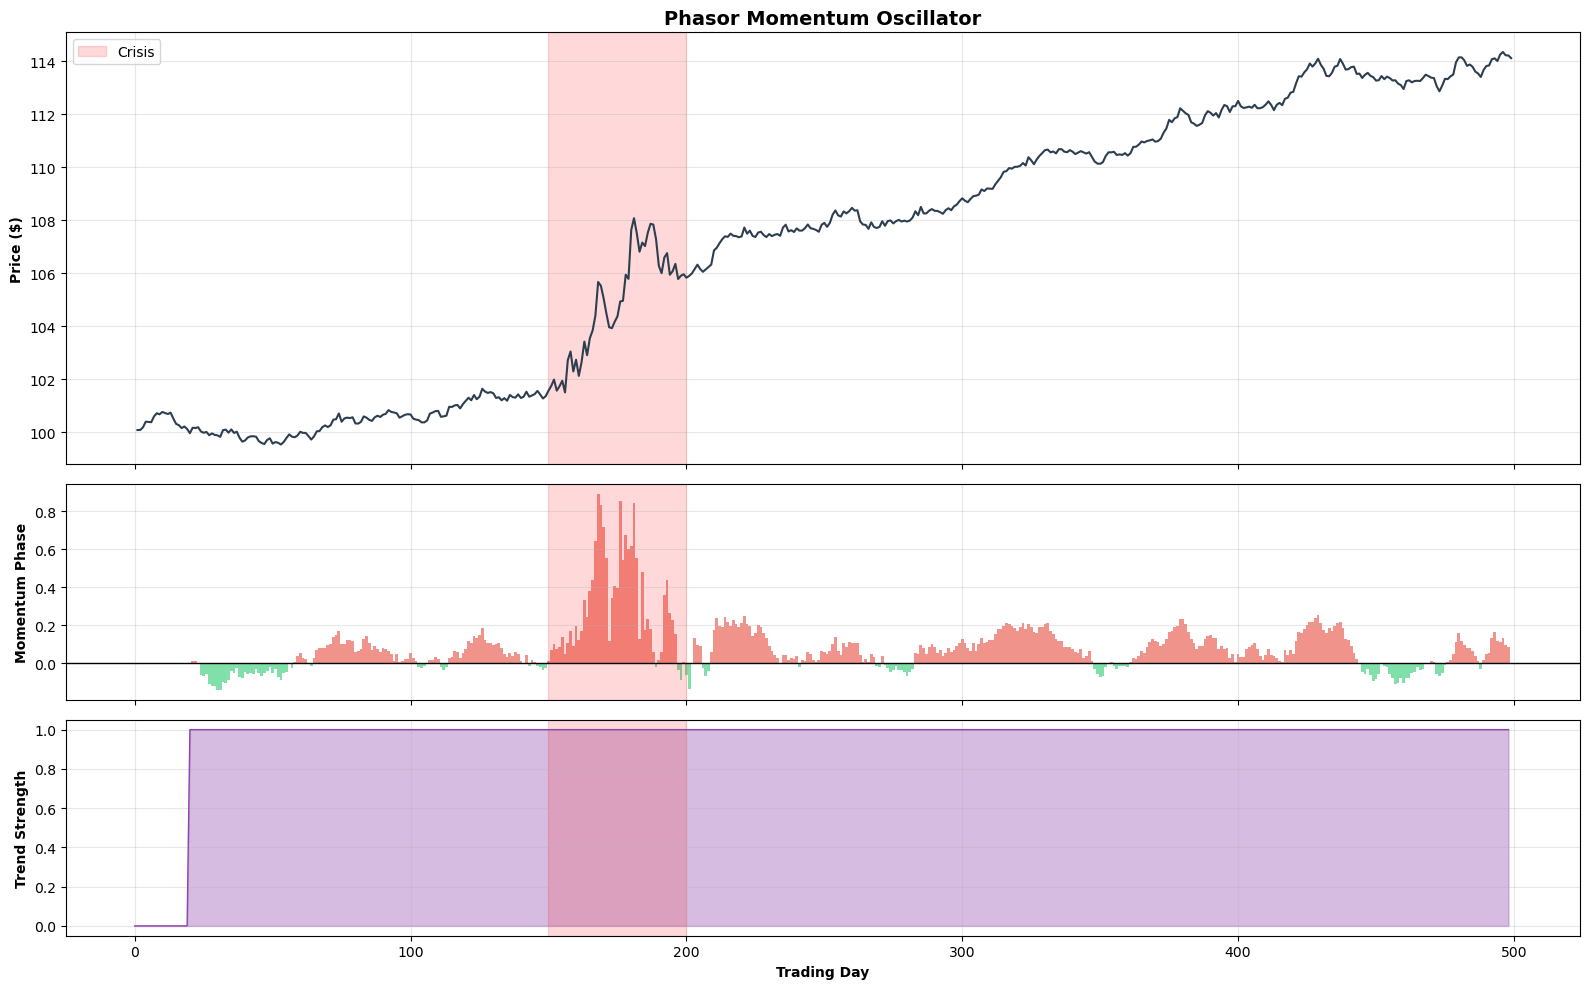


  Lookback window: 20 days
  Mean |momentum phase|: 0.1057 rad
  Interpretation: phase < 0 = bullish, phase > 0 = bearish


In [4]:
print("=" * 65)
print("  3. Phasor Momentum Oscillator")
print("=" * 65)

window = 20  # Lookback window
returns = np.diff(np.log(data['close']))  # Log returns

momentum_phase = np.zeros(len(returns))
momentum_amplitude = np.zeros(len(returns))

for t in range(window, len(returns)):
    # Get window of returns
    win_returns = returns[t-window:t]

    # Encode returns as phases: positive return → phase near 0, negative → near pi
    N = len(win_returns)
    circ = PhasorCircuit(N, name="MomentumOsc")

    for i, r in enumerate(win_returns):
        # Map return to phase: tanh scaling, then shift
        phase = math.pi * math.tanh(r * 100)  # Scale returns for sensitivity
        circ.shift(i, phase)

    circ.barrier()
    # Accumulate phases (running sum)
    circ.accumulate()
    circ.barrier()
    circ.normalize()
    circ.measure("momentum")

    result = engine.run(circ)

    snap = result['measurements']['momentum']
    if isinstance(snap, dict):
        phases = snap['phases'].detach().numpy()
        amps = snap['amplitudes'].detach().numpy()
        # Use the first thread as the momentum signal
        momentum_phase[t] = phases[0]
        momentum_amplitude[t] = amps[0]

# Normalize amplitude for visualization
if momentum_amplitude.max() > 0:
    momentum_amplitude /= momentum_amplitude.max()

# ── Visualization ──
fig, axes = plt.subplots(3, 1, figsize=(16, 10), sharex=True,
                         gridspec_kw={'height_ratios': [2, 1, 1]})

# Price
ax = axes[0]
ax.plot(range(1, len(data['close'])), data['close'][1:], color='#2c3e50', lw=1.5)
ax.axvspan(data['crisis_start'], data['crisis_end'], alpha=0.15, color='red', label='Crisis')
ax.set_ylabel('Price ($)', fontweight='bold')
ax.set_title('Phasor Momentum Oscillator', fontweight='bold', fontsize=14)
ax.legend()
ax.grid(True, alpha=0.3)

# Momentum Phase
ax = axes[1]
bullish = momentum_phase < 0
bearish = momentum_phase >= 0
t_range = range(len(momentum_phase))
for t in t_range:
    if t < window:
        continue
    color = '#2ecc71' if momentum_phase[t] < 0 else '#e74c3c'
    ax.bar(t, momentum_phase[t], color=color, alpha=0.6, width=1)
ax.axhline(y=0, color='black', lw=1)
ax.axvspan(data['crisis_start'], data['crisis_end'], alpha=0.15, color='red')
ax.set_ylabel('Momentum Phase', fontweight='bold')
ax.grid(True, alpha=0.3)

# Momentum Strength (amplitude)
ax = axes[2]
ax.fill_between(range(len(momentum_amplitude)), momentum_amplitude,
                alpha=0.4, color='#9b59b6')
ax.plot(range(len(momentum_amplitude)), momentum_amplitude,
        color='#8e44ad', lw=1)
ax.axvspan(data['crisis_start'], data['crisis_end'], alpha=0.15, color='red')
ax.set_ylabel('Trend Strength', fontweight='bold')
ax.set_xlabel('Trading Day', fontweight='bold')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\n  Lookback window: {window} days")
# Calculate basic stats
valid_phases = momentum_phase[window:]
mean_phase = np.mean(np.abs(valid_phases))
print(f"  Mean |momentum phase|: {mean_phase:.4f} rad")
print(f"  Interpretation: phase < 0 = bullish, phase > 0 = bearish")

---
## 4. Market Regime Classifier — Kuramoto Synchronization

**Idea:** Divide a sliding window of returns into `N` sub-groups representing different time horizons (e.g., 1-day, 5-day, 10-day, 20-day returns). Encode as phases and synchronize with the `Kuramoto` gate. The **order parameter** $R$ and the **mean phase** $\bar{\theta}$ classify the regime:

| $R$ | $\bar{\theta}$ | Regime |
|-----|---------------|--------|
| High | Near 0 | **Bull** (strong uptrend) |
| High | Near $\pi$ | **Bear** (strong downtrend) |
| Low | Any | **Sideways** (no consensus) |

**Gates:** `shift` (encode multi-scale returns) → `kuramoto` (×iterations) → `threshold`

  4. Market Regime Classifier (Kuramoto Synchronization)


/var/folders/mb/1xj6xtmj74j4tr0bpv9z8ms80000gn/T/ipykernel_65075/1308549052.py:70: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  ax.axvspan(data['crisis_start'], data['crisis_end'], alpha=0.08, color='red',


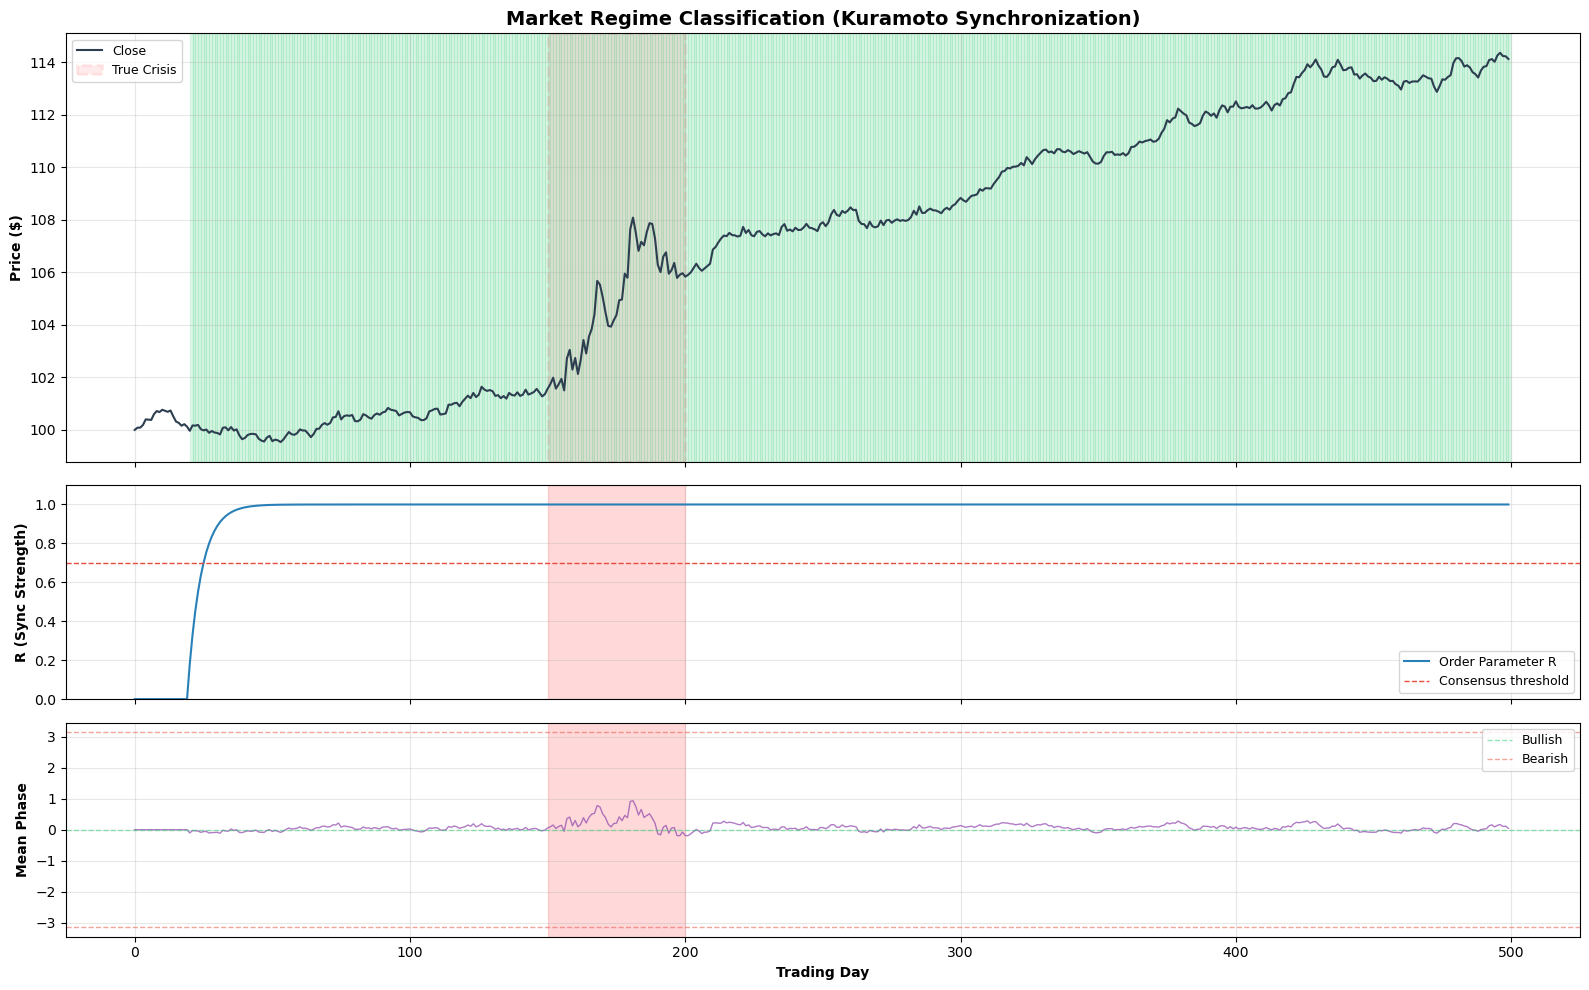


  Regime Distribution:
    Bull        :  480 days (100.0%)


In [5]:
print("=" * 65)
print("  4. Market Regime Classifier (Kuramoto Synchronization)")
print("=" * 65)

horizons = [1, 5, 10, 20]  # Multi-scale return horizons
N = len(horizons)
max_h = max(horizons)

regime_R = np.zeros(len(data['close']))          # Order parameter
regime_phase = np.zeros(len(data['close']))       # Mean phase
regime_label = [''] * len(data['close'])

# All-to-all coupling
W = torch.ones(N, N, dtype=torch.float32)
W.fill_diagonal_(0)

for t in range(max_h, len(data['close'])):
    # Multi-scale returns
    multi_returns = []
    for h in horizons:
        r = (data['close'][t] - data['close'][t-h]) / data['close'][t-h]
        multi_returns.append(r)

    # Encode as phases
    init_phases = torch.tensor([math.pi * math.tanh(r * 10) for r in multi_returns],
                               dtype=torch.float32)
    state = torch.exp(1j * init_phases)

    # Kuramoto synchronization
    for _ in range(20):
        circ = PhasorCircuit(N, name="RegimeSync")
        circ.kuramoto(W, dt=0.05, coupling_k=1.0)
        result = engine.run(circ, initial_state=state)
        state = result['state_vector']

    # Compute order parameter
    phases = torch.angle(state).detach().numpy()
    z = np.exp(1j * phases)
    R = np.abs(np.mean(z))
    mean_theta = np.angle(np.mean(z))

    regime_R[t] = R
    regime_phase[t] = mean_theta

    # Classify
    if R > 0.7:
        if abs(mean_theta) < math.pi/3:
            regime_label[t] = 'Bull'
        elif abs(mean_theta) > 2*math.pi/3:
            regime_label[t] = 'Bear'
        else:
            regime_label[t] = 'Transition'
    else:
        regime_label[t] = 'Sideways'

# Smooth R
regime_R_smooth = ema(regime_R, span=10)

# ── Visualization ──
fig, axes = plt.subplots(3, 1, figsize=(16, 10), sharex=True,
                         gridspec_kw={'height_ratios': [2, 1, 1]})

# Price with regime coloring
ax = axes[0]
regime_colors = {'Bull': '#2ecc71', 'Bear': '#e74c3c', 'Sideways': '#f39c12', 'Transition': '#9b59b6'}
for t in range(max_h, len(data['close'])):
    if regime_label[t]:
        ax.axvspan(t, t+1, alpha=0.15, color=regime_colors.get(regime_label[t], 'gray'))
ax.plot(range(len(data['close'])), data['close'], color='#2c3e50', lw=1.5, label='Close')
ax.axvspan(data['crisis_start'], data['crisis_end'], alpha=0.08, color='red',
           edgecolor='red', linestyle='--', lw=2, label='True Crisis')
ax.set_ylabel('Price ($)', fontweight='bold')
ax.set_title('Market Regime Classification (Kuramoto Synchronization)', fontweight='bold', fontsize=14)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

# Order parameter R
ax = axes[1]
ax.plot(range(len(regime_R_smooth)), regime_R_smooth, color='#2980b9', lw=1.5, label='Order Parameter R')
ax.axhline(y=0.7, color='#e74c3c', linestyle='--', lw=1, label='Consensus threshold')
ax.axvspan(data['crisis_start'], data['crisis_end'], alpha=0.15, color='red')
ax.set_ylabel('R (Sync Strength)', fontweight='bold')
ax.set_ylim(0, 1.1)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

# Mean phase
ax = axes[2]
ax.plot(range(len(regime_phase)), regime_phase, color='#8e44ad', lw=1, alpha=0.7)
ax.axhline(y=0, color='#2ecc71', linestyle='--', lw=1, alpha=0.5, label='Bullish')
ax.axhline(y=math.pi, color='#e74c3c', linestyle='--', lw=1, alpha=0.5, label='Bearish')
ax.axhline(y=-math.pi, color='#e74c3c', linestyle='--', lw=1, alpha=0.5)
ax.axvspan(data['crisis_start'], data['crisis_end'], alpha=0.15, color='red')
ax.set_ylabel('Mean Phase', fontweight='bold')
ax.set_xlabel('Trading Day', fontweight='bold')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Summary statistics
from collections import Counter
regime_counts = Counter([r for r in regime_label if r])
total = sum(regime_counts.values())
print(f"\n  Regime Distribution:")
for regime, count in sorted(regime_counts.items()):
    print(f"    {regime:12s}: {count:4d} days ({count/total*100:.1f}%)")

---
## 5. Phasor Pair-Trading Signal — Cross-Correlation on the Circle

**Idea:** Generate two correlated assets using GBM with shared and idiosyncratic components. Encode their rolling returns as phases, then use `CrossCorrelate` to measure their phase relationship. When the cross-correlation phase diverges from historical norm, it signals a **mean-reversion trade**.

**Gates:** `shift` (encode returns) → `cross_correlate` → `threshold`

**Application:** Statistical arbitrage, pairs trading.

  5. Phasor Pair-Trading Signal (Cross-Correlation)


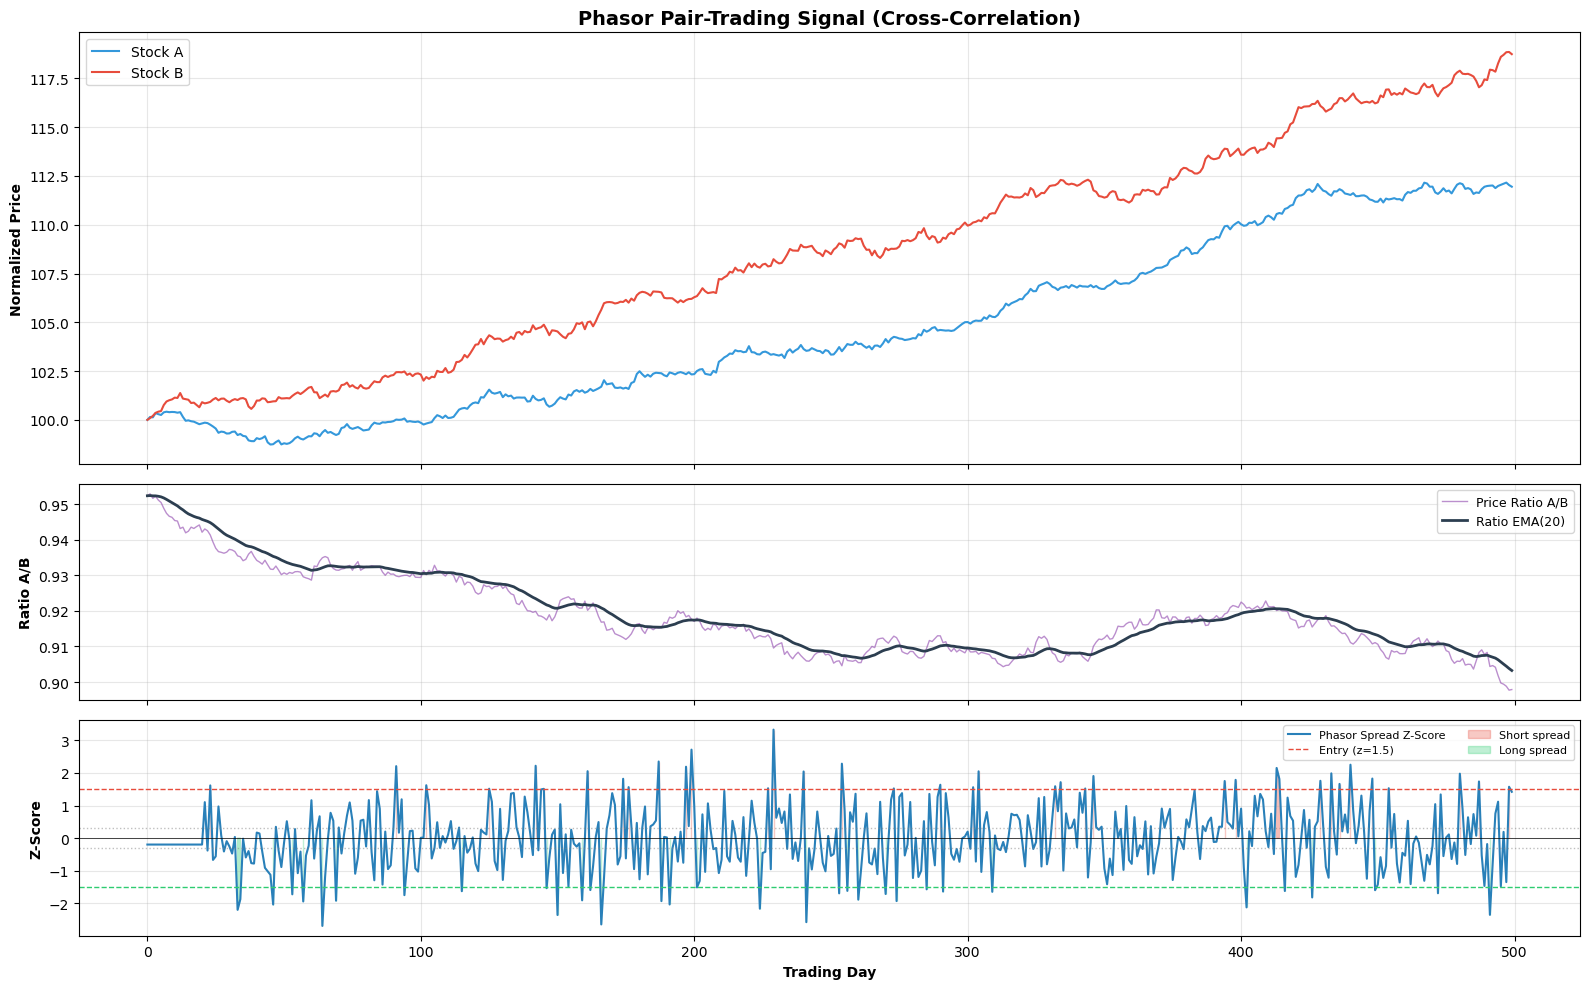


  Pair correlation: 0.8
  Long spread signals: 33 days
  Short spread signals: 37 days
  Total signal days: 70 / 500


In [6]:
print("=" * 65)
print("  5. Phasor Pair-Trading Signal (Cross-Correlation)")
print("=" * 65)

# Generate a correlated pair
np.random.seed(42)
n_days = 500
dt = 1/252
correlation = 0.8  # High correlation between pair

# Shared market factor and idiosyncratic components
market = np.random.standard_normal(n_days)
stock_a_noise = np.random.standard_normal(n_days)
stock_b_noise = np.random.standard_normal(n_days)

sigma_a, sigma_b = 0.02, 0.025
mu_a, mu_b = 0.05, 0.06

S_a = np.zeros(n_days); S_a[0] = 100
S_b = np.zeros(n_days); S_b[0] = 105

for t in range(1, n_days):
    z_a = correlation * market[t] + np.sqrt(1 - correlation**2) * stock_a_noise[t]
    z_b = correlation * market[t] + np.sqrt(1 - correlation**2) * stock_b_noise[t]
    S_a[t] = S_a[t-1] * np.exp((mu_a - 0.5*sigma_a**2)*dt + sigma_a*np.sqrt(dt)*z_a)
    S_b[t] = S_b[t-1] * np.exp((mu_b - 0.5*sigma_b**2)*dt + sigma_b*np.sqrt(dt)*z_b)

# Compute rolling phasor cross-correlation
window = 20
spread_phase = np.zeros(n_days)
spread_amp = np.zeros(n_days)

ret_a = np.diff(np.log(S_a))
ret_b = np.diff(np.log(S_b))

for t in range(window, len(ret_a)):
    win_a = ret_a[t-window:t]
    win_b = ret_b[t-window:t]

    N = window
    circ = PhasorCircuit(N, name="PairSignal")

    # Encode stock A returns as circuit phases
    for i, r in enumerate(win_a):
        circ.shift(i, math.pi * math.tanh(r * 200))

    circ.barrier()
    # Cross-correlate with stock B returns as pattern
    pattern_b = torch.tensor([math.pi * math.tanh(r * 200) for r in win_b],
                             dtype=torch.float32)
    circ.cross_correlate(pattern_b)
    circ.barrier()
    circ.normalize()
    circ.measure("pair_signal")

    result = engine.run(circ)
    snap = result['measurements']['pair_signal']
    if isinstance(snap, dict):
        phases = snap['phases'].detach().numpy()
        amps = snap['amplitudes'].detach().numpy()
        spread_phase[t+1] = phases[0]
        spread_amp[t+1] = amps[0]

# Normalize spread
if np.max(np.abs(spread_phase)) > 0:
    zscore_spread = (spread_phase - np.mean(spread_phase[window:])) / (np.std(spread_phase[window:]) + 1e-8)
else:
    zscore_spread = spread_phase

# Trading signals
entry_z = 1.5
exit_z = 0.3

# ── Visualization ──
fig, axes = plt.subplots(3, 1, figsize=(16, 10), sharex=True,
                         gridspec_kw={'height_ratios': [2, 1, 1]})

# Normalized prices
ax = axes[0]
ax.plot(range(n_days), S_a / S_a[0] * 100, color='#3498db', lw=1.5, label='Stock A')
ax.plot(range(n_days), S_b / S_b[0] * 100, color='#e74c3c', lw=1.5, label='Stock B')
ax.set_ylabel('Normalized Price', fontweight='bold')
ax.set_title('Phasor Pair-Trading Signal (Cross-Correlation)', fontweight='bold', fontsize=14)
ax.legend()
ax.grid(True, alpha=0.3)

# Price ratio
ax = axes[1]
ratio = S_a / S_b
ratio_ma = ema(ratio, span=20)
ax.plot(range(n_days), ratio, color='#8e44ad', lw=1, alpha=0.6, label='Price Ratio A/B')
ax.plot(range(n_days), ratio_ma, color='#2c3e50', lw=2, label='Ratio EMA(20)')
ax.set_ylabel('Ratio A/B', fontweight='bold')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

# Phasor spread signal
ax = axes[2]
ax.plot(range(n_days), zscore_spread, color='#2980b9', lw=1.5, label='Phasor Spread Z-Score')
ax.axhline(y=entry_z, color='#e74c3c', linestyle='--', lw=1, label=f'Entry (z={entry_z})')
ax.axhline(y=-entry_z, color='#2ecc71', linestyle='--', lw=1)
ax.axhline(y=exit_z, color='gray', linestyle=':', lw=1, alpha=0.5)
ax.axhline(y=-exit_z, color='gray', linestyle=':', lw=1, alpha=0.5)
ax.axhline(y=0, color='black', lw=0.5)
ax.fill_between(range(n_days), zscore_spread, 0,
                where=zscore_spread > entry_z, alpha=0.3, color='#e74c3c', label='Short spread')
ax.fill_between(range(n_days), zscore_spread, 0,
                where=zscore_spread < -entry_z, alpha=0.3, color='#2ecc71', label='Long spread')
ax.set_ylabel('Z-Score', fontweight='bold')
ax.set_xlabel('Trading Day', fontweight='bold')
ax.legend(fontsize=8, ncol=2)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Count signals
long_signals = np.sum(zscore_spread < -entry_z)
short_signals = np.sum(zscore_spread > entry_z)
print(f"\n  Pair correlation: {correlation}")
print(f"  Long spread signals: {long_signals} days")
print(f"  Short spread signals: {short_signals} days")
print(f"  Total signal days: {long_signals + short_signals} / {n_days}")

---
## 6. Volatility Surface Attractor — Hebbian Pattern Recognition

**Idea:** The volatility term structure (short-term vs long-term vol) tends to cluster into distinct **regimes** (contango, backwardation, flat). We store these canonical patterns in a Hebbian weight matrix, then use associative memory recall to classify each day's volatility structure.

This is analogous to a **self-organizing volatility classifier** — the network has learned the canonical shapes and recognizes which one the market is closest to.

**Gates:** `shift` (encode vol features) → `hebbian` (×iterations) → `saturate` (snap to binary)

  6. Volatility Surface Attractor (Hebbian Classification)


/var/folders/mb/1xj6xtmj74j4tr0bpv9z8ms80000gn/T/ipykernel_65075/3978310020.py:99: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  ax.axvspan(data['crisis_start'], data['crisis_end'], alpha=0.08, color='red',


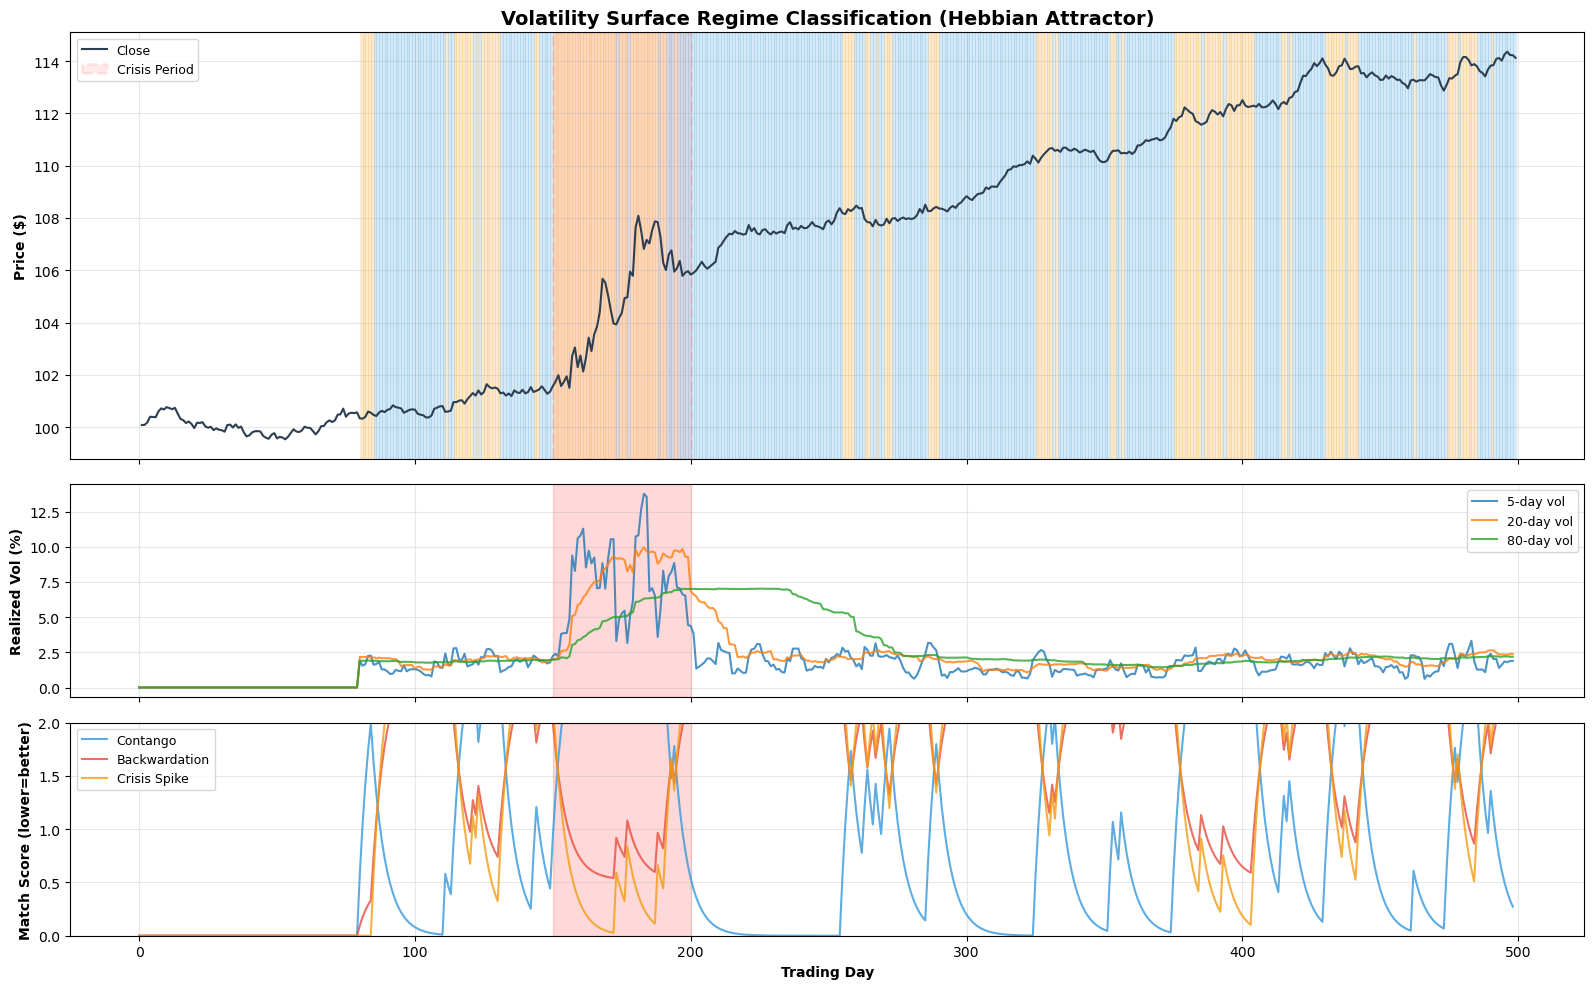


  Volatility Regime Distribution:
    Contango       :  280 days (66.8%)
    Crisis Spike   :  139 days (33.2%)


In [7]:
print("=" * 65)
print("  6. Volatility Surface Attractor (Hebbian Classification)")
print("=" * 65)

# Compute realized volatility at multiple horizons
vol_windows = [5, 10, 20, 40, 60, 80]
N = len(vol_windows)

log_returns = np.diff(np.log(data['close']))

# Build volatility term structure for each day
vol_surface = np.zeros((len(log_returns), N))
max_win = max(vol_windows)

for t in range(max_win, len(log_returns)):
    for i, w in enumerate(vol_windows):
        vol_surface[t, i] = np.std(log_returns[t-w:t]) * np.sqrt(252)  # Annualized

# Define canonical vol regimes as binary patterns (0 or pi)
# Contango: short vol < long vol → increasing pattern
# Backwardation: short vol > long vol → decreasing pattern
# Flat: uniform

contango =      [0, 0, math.pi, math.pi, math.pi, math.pi]    # Low-High
backwardation = [math.pi, math.pi, math.pi, 0, 0, 0]           # High-Low
crisis_spike =  [math.pi, math.pi, 0, 0, 0, 0]                 # Spike then decay

patterns = [contango, backwardation, crisis_spike]
pattern_names = ['Contango', 'Backwardation', 'Crisis Spike']

# Store patterns in Hebbian weights
W = HebbianGate.store_patterns(N, patterns)

# Classify each day
regime_labels = []
regime_scores = np.zeros((len(log_returns), len(patterns)))

for t in range(max_win, len(log_returns)):
    # Normalize vol surface for this day
    vs = vol_surface[t]
    if vs.max() - vs.min() > 0:
        vs_norm = (vs - vs.min()) / (vs.max() - vs.min())
    else:
        vs_norm = np.zeros(N)

    # Map to phases: low vol → 0, high vol → pi
    phases = vs_norm * math.pi

    # Build circuit
    circ = PhasorCircuit(N, name="VolClassifier")
    for i in range(N):
        circ.shift(i, phases[i])
    circ.barrier()

    for _ in range(30):
        circ.hebbian(W, alpha=0.1)
    circ.barrier()
    circ.saturate(levels=2)
    circ.measure("regime")

    result = engine.run(circ)
    snap = result['measurements']['regime']

    if isinstance(snap, dict):
        recalled_phases = snap['phases'].detach().numpy()

        # Match to closest pattern
        best_match = -1
        best_score = float('inf')
        for pi, pat in enumerate(patterns):
            pat_arr = np.array(pat)
            # Circular distance
            diff = np.abs(recalled_phases - pat_arr)
            diff = np.minimum(diff, 2*math.pi - diff)
            score = np.mean(diff)
            regime_scores[t, pi] = score
            if score < best_score:
                best_score = score
                best_match = pi

        regime_labels.append(pattern_names[best_match])
    else:
        regime_labels.append('Unknown')

# Pad for alignment
while len(regime_labels) < len(log_returns):
    regime_labels.insert(0, 'Unknown')

# ── Visualization ──
fig, axes = plt.subplots(3, 1, figsize=(16, 10), sharex=True,
                         gridspec_kw={'height_ratios': [2, 1, 1]})

# Price with vol regime coloring
ax = axes[0]
vol_colors = {'Contango': '#3498db', 'Backwardation': '#e74c3c', 'Crisis Spike': '#f39c12', 'Unknown': 'white'}
for t in range(max_win, len(regime_labels)):
    ax.axvspan(t, t+1, alpha=0.15, color=vol_colors.get(regime_labels[t], 'gray'))
ax.plot(range(1, len(data['close'])), data['close'][1:], color='#2c3e50', lw=1.5, label='Close')
ax.axvspan(data['crisis_start'], data['crisis_end'], alpha=0.08, color='red',
           edgecolor='red', linestyle='--', lw=2, label='Crisis Period')
ax.set_ylabel('Price ($)', fontweight='bold')
ax.set_title('Volatility Surface Regime Classification (Hebbian Attractor)', fontweight='bold', fontsize=14)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

# Vol term structure
ax = axes[1]
for i, w in enumerate(vol_windows):
    if i in [0, 2, 5]:  # Show 3 representative horizons
        ax.plot(range(len(log_returns)), vol_surface[:, i] * 100,
                lw=1.5, alpha=0.8, label=f'{w}-day vol')
ax.axvspan(data['crisis_start'], data['crisis_end'], alpha=0.15, color='red')
ax.set_ylabel('Realized Vol (%)', fontweight='bold')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

# Pattern match scores
ax = axes[2]
for pi, name in enumerate(pattern_names):
    # Smooth scores
    scores_smooth = ema(regime_scores[:, pi], span=10)
    ax.plot(range(len(log_returns)), scores_smooth,
            lw=1.5, alpha=0.8, label=name, color=list(vol_colors.values())[pi])
ax.axvspan(data['crisis_start'], data['crisis_end'], alpha=0.15, color='red')
ax.set_ylabel('Match Score (lower=better)', fontweight='bold')
ax.set_xlabel('Trading Day', fontweight='bold')
ax.legend(fontsize=9)
ax.set_ylim(0, 2.0)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Summary
from collections import Counter
valid_labels = [r for r in regime_labels if r != 'Unknown']
regime_dist = Counter(valid_labels)
total = len(valid_labels)
print(f"\n  Volatility Regime Distribution:")
for regime, count in sorted(regime_dist.items()):
    pct = count / total * 100 if total > 0 else 0
    print(f"    {regime:15s}: {count:4d} days ({pct:.1f}%)")

---
## Summary

| # | Application | Key Insight |
|---|-------------|-------------|
| 1 | GBM Data Generator | Geometric Brownian Motion with crisis regime produces realistic OHLCV |
| 2 | Phase Coherence Detector | Phase coherence drops during crises → non-linear volatility indicator |
| 3 | Momentum Oscillator | Accumulated phase reveals trend direction; amplitude reveals strength |
| 4 | Regime Classifier | Kuramoto synchronization of multi-scale returns detects Bull/Bear/Sideways |
| 5 | Pair-Trading Signal | Phase cross-correlation of spread returns generates mean-reversion signals |
| 6 | Vol Surface Attractor | Hebbian memory classifies volatility term structure into canonical regimes |

> **Key insight:** The unit circle provides a natural manifold for financial data — returns map to phases, volatility maps to amplitudes, and phasor gates (Mix, DFT, Kuramoto, CrossCorrelate, Hebbian) extract non-linear relationships invisible to traditional linear analysis.

> **Why phasors for finance?** Financial time series are inherently **oscillatory** (business cycles, mean reversion, seasonality). Phasor computing operates natively on oscillatory signals, making it a mathematically natural framework for market analysis — just as Fourier analysis revolutionized signal processing.